#Datos del alumno

Alumno: Octavio Quintero Flores

Matricula: 266226

In [2]:
#Importamos las librerias asi como tambien el dataset de california housing de sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [3]:
# Cargar dataset
data = fetch_california_housing()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target

# Ver primeras filas
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


#Analisis de los datos

In [4]:
#Revisamos como esta el dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

In [5]:
#Variable objetivo
y = df["MedHouseVal"]

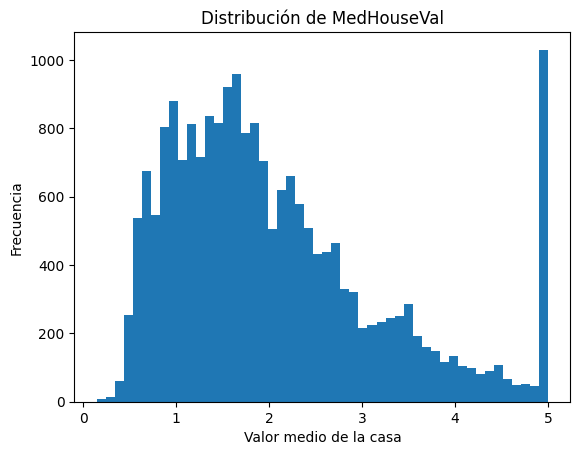

In [6]:
#Visualizamos la variable objetivo
plt.hist(y, bins=50)
plt.title("Distribución de MedHouseVal")
plt.xlabel("Valor medio de la casa")
plt.ylabel("Frecuencia")
plt.show()

#Creacion del modelo

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Hacemos y nuestra variable objetivo y x sera nuestras variables predictorias, estas seran todas las demas variables.

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Modelo base
tree = DecisionTreeRegressor(max_depth=None, random_state=42)
tree.fit(X_train, y_train)

# Predicciones
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

# Métricas
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Train R2:", r2_train)
print("Test R2:", r2_test)

Train RMSE: 3.218325866275131e-16
Test RMSE: 0.7037294974840077
Train R2: 1.0
Test R2: 0.622075845135081


Podemos ver como realiza muy bien los train pero los test no tan bien.

#Bias-Variance

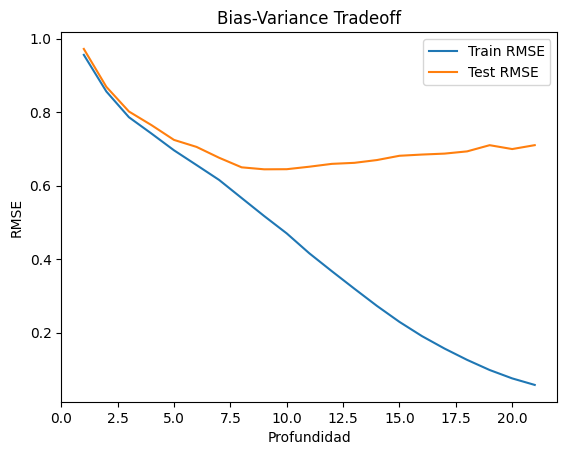

In [9]:
train_errors = []
test_errors = []
depths = range(1, 22)

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_errors.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Gráfica
plt.plot(depths, train_errors, label="Train RMSE")
plt.plot(depths, test_errors, label="Test RMSE")
plt.xlabel("Profundidad")
plt.ylabel("RMSE")
plt.legend()
plt.title("Bias-Variance Tradeoff")
plt.show()

A medida que aumenta la profundidad, el error en entrenamiento disminuye continuamente. Sin embargo, el error en test primero disminuye (mejorando la generalización) y luego aumenta debido al sobreajuste. Esto evidencia el trade-off entre bias y varianza.

#Poda

In [11]:
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# reducir
ccp_alphas = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 30)

train_errors = []
test_errors = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)

    train_errors.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train))))
    test_errors.append(np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

Se evaluó el efecto de la poda variando el parámetro ccp_alpha. Para cada valor, se entrenó un modelo y se calculó el RMSE en entrenamiento y prueba, permitiendo analizar cómo la reducción de complejidad afecta el desempeño.

#Grafica del efecto de la poda

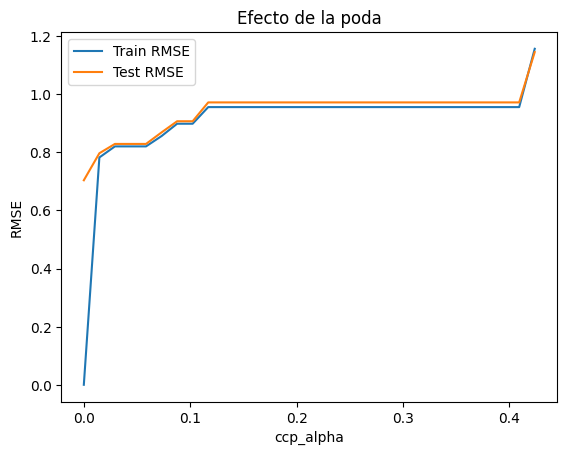

In [12]:
plt.plot(ccp_alphas, train_errors, label="Train RMSE")
plt.plot(ccp_alphas, test_errors, label="Test RMSE")
plt.xlabel("ccp_alpha")
plt.ylabel("RMSE")
plt.legend()
plt.title("Efecto de la poda")
plt.show()

In [13]:
print("Alphas:", ccp_alphas[:5])
print("Train RMSE:", train_errors[:5])
print("Test RMSE:", test_errors[:5])

Alphas: [0.         0.01461221 0.02922443 0.04383664 0.05844885]
Train RMSE: [np.float64(3.218325866275131e-16), np.float64(0.7822335601433086), np.float64(0.8202914538177196), np.float64(0.8202914538177196), np.float64(0.8202914538177196)]
Test RMSE: [np.float64(0.7037294974840077), np.float64(0.7967523235489674), np.float64(0.8287840763112735), np.float64(0.8287840763112735), np.float64(0.8287840763112735)]


Estas líneas imprimen una muestra de los valores de ccp_alpha y los errores asociados para verificar el comportamiento del modelo sin mostrar toda la lista.

#Importancia de variables

In [14]:
best_model = DecisionTreeRegressor(max_depth=5, random_state=42)
best_model.fit(X_train, y_train)

importances = pd.Series(best_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

MedInc        0.771212
AveOccup      0.128407
HouseAge      0.041621
AveRooms      0.031261
Latitude      0.022049
Population    0.002485
Longitude     0.002097
AveBedrms     0.000869
dtype: float64


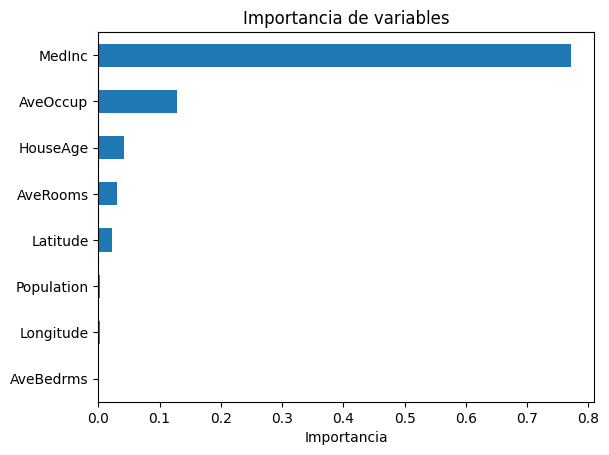

In [15]:
importances.sort_values().plot(kind="barh")
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.show()

#Interpretación de resultados

**¿El modelo base presenta sobreajuste? Explique**

Sí,

RMSE entrenamiento ≈ 0

R² entrenamiento = 1.0

RMSE test ≈ 0.70

R² test ≈ 0.62

El modelo aprende los datos de entrenamiento, pero pierde precisión en datos nuevos.

Conclusión:

El árbol sin restricciones tiene alta varianza y memoriza en lugar de generalizar.

**¿Cómo afecta la profundidad del árbol al error?**

La profundidad controla la complejidad del modelo:

Baja profundidad

Alto error en train y test - Underfitting (alto bias)

Profundidad media

Error balanceado - Mejor generalización

Alta profundidad

Error train ≈ 0

Error test alto - Overfitting (alta varianza)


**¿Qué efecto tiene la poda en el modelo?**

La poda (ccp_alpha) reduce la complejidad del árbol:

* Elimina ramas poco relevantes
* Aumenta el error en entrenamiento
* Puede reducir el error en test

En mi caso:

Valores grandes de ccp_alpha empeoran el modelo, esto indica que la poda fue demasiado agresiva.

Por lo cual se necesitan valores pequeños de ccp_alpha para mejorar.

**¿Cuál configuración produce el mejor desempeño?**

El mejor modelo es el árbol sin poda (ccp_alpha = 0), esto por los valores en los cuales intente, no significa que sea el óptimo.

**¿Qué variables son más relevantes según el modelo?**

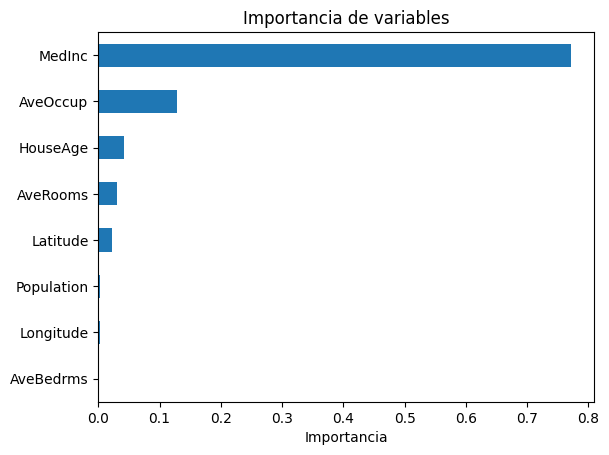